<h3>Invoke the load_iris() function to load the data.<h3>

In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [1]:
from sklearn import datasets
iris = datasets.load_iris()

<h3>The iris object returned by load_iris is a Bunch object, which is very similar to a dictionary, and it contains keys and values inside.<h3> 

In [3]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

<h3>The value of the DESCR key is a simple explanation of the dataset.<h3> 

In [4]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

<h3>The value of the feature_names key is a list of strings that explains each feature.<h3>

In [5]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

<h3>The value of the target_names key is a string array, containing the species of Iris flowers that we are to predict.<h3>

In [6]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

<h3>The data is contained in the target and data fields.Inside the data are the sepal length, sepal width, petal length and petal width. The data is in the form of a NumPy array, and each row of the data array corresponds to a flower, and the columns represent the four measurement data of eachf lower.<h3>

In [17]:
iris.data[0]

array([5.1, 3.5, 1.4, 0.2])

In [10]:
iris.data.shape

(150, 4)

<h3>The target array contains the species of each measured flower, which is also a NumPyarray, and the species are converted into integers ranging from 0 to 2: 0 stands for setosa, 1 stands for versicolor, and 2 stands for virginica.<h3>

In [13]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [14]:
iris.target.shape

(150,)

<h2>Data analysis<h2>

<h3>The bellow graph shows relationship between the sepal length and width.<h3>

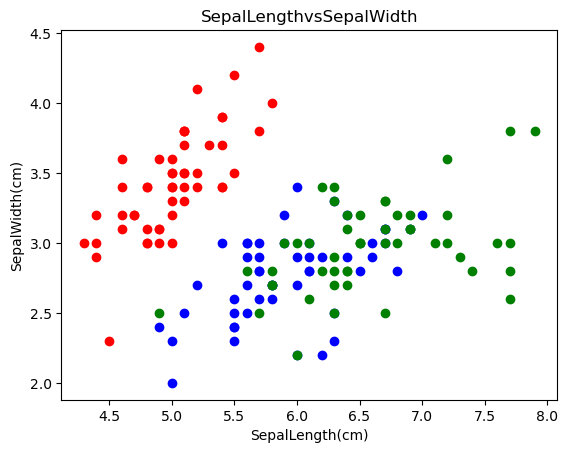

In [16]:
X=iris.data[:,:2]
y=iris.target
plt.scatter(X[y==0,0],X[y==0,1],color='red')
plt.scatter(X[y==1,0],X[y==1,1],color='blue')
plt.scatter(X[y==2,0],X[y==2,1],color='green')
plt.xlabel('SepalLength(cm)')
plt.ylabel('SepalWidth(cm)')
plt.title('SepalLengthvsSepalWidth')
plt.show()

<h3>Now we will check relationship between the petal length and width.<h3>

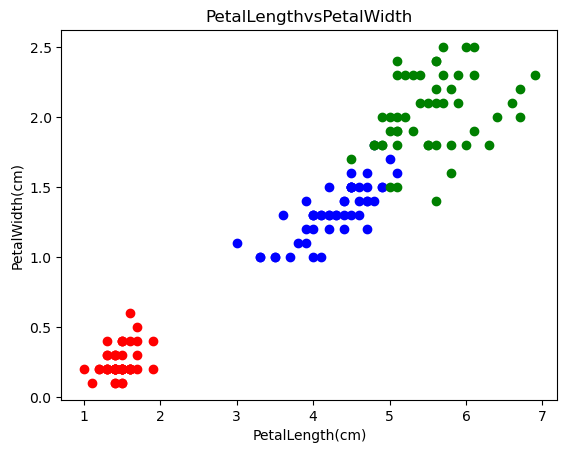

In [18]:
X=iris.data[:,2:]
plt.scatter(X[y==0,0],X[y==0,1],color='red')
plt.scatter(X[y==1,0],X[y==1,1],color='blue')
plt.scatter(X[y==2,0],X[y==2,1],color='green')
plt.xlabel('PetalLength(cm)')
plt.ylabel('PetalWidth(cm)')
plt.title('PetalLengthvsPetalWidth')
plt.show()

<h4>As we can see that the Petal Features are giving a better cluster division compared to the Sepal features. This is an indication that the Petals can help in better and accurate Predictions over the Sepal We will check that later.<h4>

<h3>The heat map allows for easy interpretation of which features are positively or negatively correlated with one another in the dataset.<h3>
<h4>When we train any algorithm, the number of features and their correlation plays an important role. If there are features and many of the features are highly correlated, then training an algorithm with all the features will reduce the accuracy. Thus  features selection should be done carefully. This dataset has less features but still we will see the correlation.<h4>

In [22]:
!pip install seaborn 
import seaborn as sns

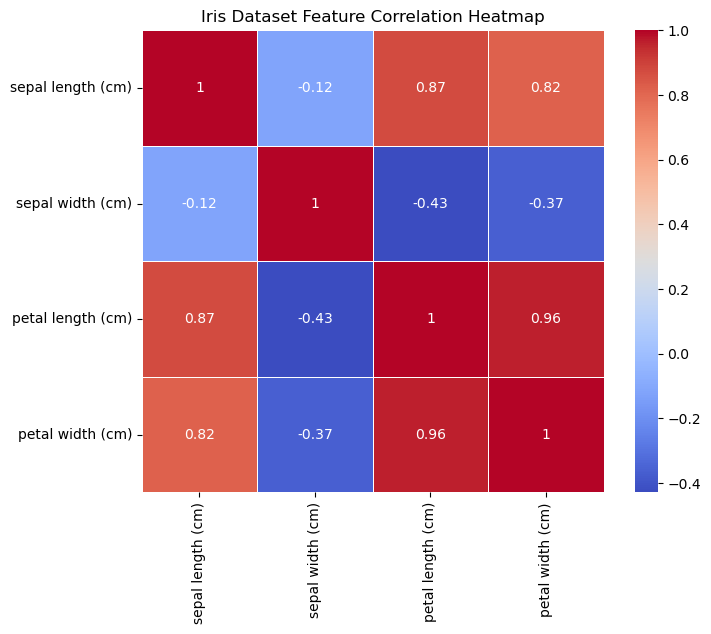

In [25]:
X=iris.data
correlation_matrix=np.corrcoef(iris.data,rowvar=False)
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',linewidths=.5,square=True,xticklabels=iris.feature_names,yticklabels=iris.feature_names)
plt.title('Iris Dataset Feature Correlation Heatmap')
plt.show()

<h2>Model Training<h2>

<h4>Splitting The Data into Training And Testing Dataset:<h4>

In [32]:
from sklearn.model_selection import train_test_split

X = iris.data
y = iris.target

test_size = 0.3

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = test_size, random_state = 48)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 105 samples
Test set size: 45 samples


<h4>Initialize and train the KNN classifier model:<h4>

In [33]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

<h4>Make predictions on the testing data<h4>

In [36]:
y_pred = knn.predict(X_test)
y_pred

array([1, 1, 2, 0, 1, 2, 0, 1, 0, 1, 2, 0, 0, 2, 1, 1, 0, 1, 2, 2, 0, 2,
       1, 1, 2, 0, 0, 2, 2, 1, 2, 1, 2, 0, 1, 2, 2, 1, 0, 1, 1, 1, 2, 2,
       1])

<h4>Evaluate the model's accuracy:<h4>

In [37]:
from sklearn.metrics import accuracy_score

print("\nAccuracy Score:", accuracy_score(y_test,y_pred))


Accuracy Score: 0.9555555555555556


<h4>Let's check the accuracy for various values of n for K-Nearest nerighbours.<h4>

k =  1  Accuracy Score: 0.9555555555555556
k =  2  Accuracy Score: 0.9111111111111111
k =  3  Accuracy Score: 0.9555555555555556
k =  4  Accuracy Score: 0.9333333333333333
k =  5  Accuracy Score: 0.9555555555555556
k =  6  Accuracy Score: 0.9333333333333333
k =  7  Accuracy Score: 0.9555555555555556
k =  8  Accuracy Score: 0.9555555555555556
k =  9  Accuracy Score: 1.0
k =  10  Accuracy Score: 0.9555555555555556


([<matplotlib.axis.XTick at 0x246568acfd0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

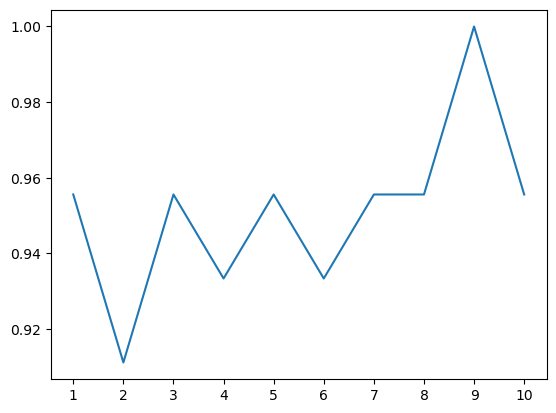

In [43]:
k_values = np.arange(1,11)

accuracy_scores = np.zeros(k_values.shape)

for i,k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    
    knn.fit(X_train,y_train)
    
    predictions = knn.predict(X_test)
    
    accuracy_scores[i] = accuracy_score(predictions,y_test)
    
    print("k = ",k," Accuracy Score:", accuracy_scores[i])
    
plt.plot(k_values,accuracy_scores)
plt.xticks(np.arange(1,11))

<h4>Above is the graph showing the accuracy for the KNN models using different values
of k. We used all the features of iris in above models. Now we will use Petals and Sepals
separately<h4>

<h3>Creating Petals And Sepals Training Data<h3>

In [45]:
X_sepal = iris.data[:,:2]

X_petal = iris.data[:,2:]

test_size = 0.3

X_train_sepal, X_test_sepal, y_train_sepal, y_test_sepal = train_test_split(X_sepal,y,test_size=test_size, random_state=0)

X_train_petal, X_test_petal, y_train_petal, y_test_petal = train_test_split(X_petal,y,test_size=test_size, random_state=0)


<h4>K-Nearest Neighbours<h4>

In [47]:
knn_Sepal = KNeighborsClassifier(n_neighbors=3)

knn_Sepal.fit(X_train_sepal,y_train_sepal)

prediction = knn_Sepal.predict(X_test_sepal)

print('The accuracy of the KNN using Sepal is: ',accuracy_score(prediction,y_test_sepal))

knn_Petal = KNeighborsClassifier(n_neighbors=3)

knn_Petal.fit(X_train_petal,y_train_petal)

prediction = knn_Petal.predict(X_test_petal)

print('The accuracy of the KNN using Petal is: ',accuracy_score(prediction,y_test_petal))

The accuracy of the KNN using Sepal is:  0.7333333333333333
The accuracy of the KNN using Petal is:  0.9777777777777777
